In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([0.2, 0.02])

# train_data = "../data/output_train.npz"
# valid_data = "../data/output_valid.npz"

train_data = "../data/combined_output_new_train.npz"
valid_data = "../data/combined_output_new_test.npz"

train_file = "training_data.npz"
valid_file = "validation_data.npz"
# convert to direct-BC format
convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


Saved converted direct-BC dataset to: training_data.npz
qs.shape      = (2, 11, 11)
xb.shape      = (2, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)
Saved converted direct-BC dataset to: validation_data.npz
qs.shape      = (2, 11, 11)
xb.shape      = (2, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)


In [3]:
params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(42),
    hidden=(10,),
    which_case="MLP",
    corr_factor=1,
    input_mode="raw",
    zero_reference=True,
    activation="tanh",
)
final_model, train_history, valid_history = train_model(DiagonalPlusStiffnessNN, params=params, train_file=train_file, valid_file=valid_file, n_epochs=500, lr=5e-2)

Epoch 000 | Train: 1.175e-03 | Valid: 7.061e-04
Epoch 010 | Train: 1.505e-04 | Valid: 1.645e-04
Epoch 020 | Train: 1.069e-04 | Valid: 1.186e-04
Epoch 030 | Train: 4.294e-05 | Valid: 4.891e-05
Epoch 040 | Train: 2.955e-05 | Valid: 2.427e-05
Epoch 050 | Train: 2.013e-05 | Valid: 2.869e-05
Epoch 060 | Train: 1.394e-05 | Valid: 2.044e-05
Epoch 070 | Train: 1.046e-05 | Valid: 1.890e-05
Epoch 080 | Train: 8.275e-06 | Valid: 1.681e-05
Epoch 090 | Train: 6.714e-06 | Valid: 1.605e-05
Epoch 100 | Train: 5.536e-06 | Valid: 1.493e-05
Epoch 110 | Train: 4.605e-06 | Valid: 1.400e-05
Epoch 120 | Train: 3.865e-06 | Valid: 1.329e-05
Epoch 130 | Train: 3.267e-06 | Valid: 1.267e-05
Epoch 140 | Train: 2.777e-06 | Valid: 1.214e-05
Epoch 150 | Train: 2.375e-06 | Valid: 1.170e-05
Epoch 160 | Train: 2.041e-06 | Valid: 1.132e-05
Epoch 170 | Train: 1.764e-06 | Valid: 1.099e-05
Epoch 180 | Train: 1.534e-06 | Valid: 1.071e-05
Epoch 190 | Train: 1.341e-06 | Valid: 1.047e-05
Epoch 200 | Train: 1.181e-06 | Valid: 1.

500


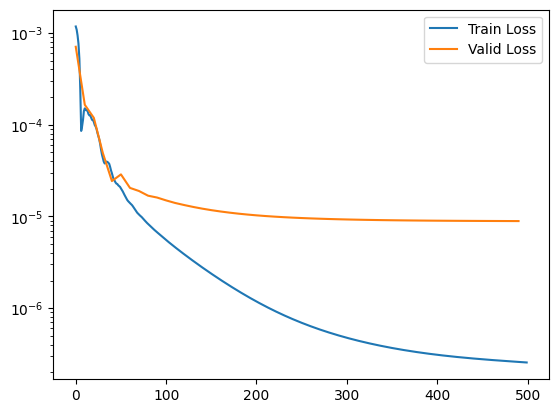

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
base, aux = get_slinky()
valid = Dataset.load(valid_file)
pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

In [6]:
animate(pred[0])

In [7]:
animate(valid.qs[0])

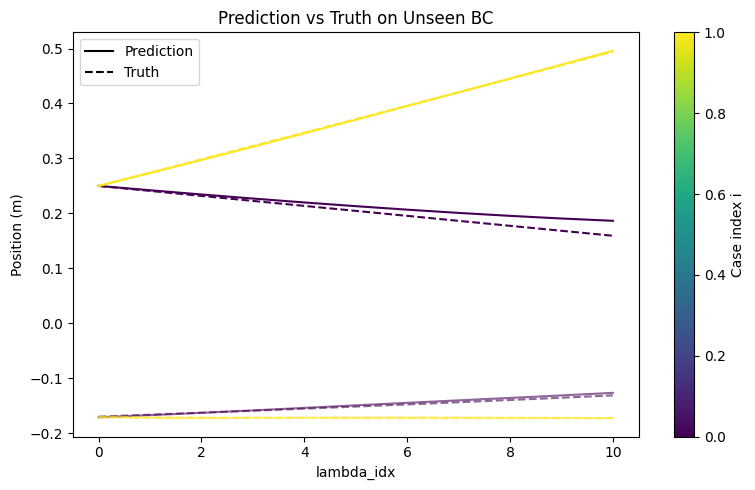

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()